In [1]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# --- 1. DYNAMIC PATH LOCATOR ---
print("🔍 Scanning for datasets...")
ham_metadata_path = ""
ham_images_dict = {}
natural_images_path = ""

for dirname, _, filenames in os.walk('/kaggle/input'):
    if 'HAM10000_metadata.csv' in filenames:
        ham_metadata_path = os.path.join(dirname, 'HAM10000_metadata.csv')
    if 'natural_images' in dirname and not natural_images_path:
        natural_images_path = dirname
    for filename in filenames:
        if filename.endswith('.jpg') and 'natural_images' not in dirname:
            ham_images_dict[filename.split('.')[0]] = os.path.join(dirname, filename)

# --- 2. DATA PROCESSING ---
df = pd.read_csv(ham_metadata_path)
df['path'] = df['image_id'].map(ham_images_dict)
df = df.dropna(subset=['path'])

# Add NOT_MEDICAL class
ood_samples = []
for folder in os.listdir(natural_images_path):
    f_path = os.path.join(natural_images_path, folder)
    if os.path.isdir(f_path):
        imgs = [f for f in os.listdir(f_path) if f.endswith(('.jpg', '.jpeg', '.png'))]
        for img_file in imgs[:200]: 
            ood_samples.append([os.path.join(f_path, img_file), 'not_medical'])

full_df = pd.concat([df[['path', 'dx']], pd.DataFrame(ood_samples, columns=['path', 'dx'])], ignore_index=True)

print(f"✅ Dataset Unified: {len(full_df)} total images.")
print(full_df['dx'].value_counts())

2026-05-01 17:52:09.843620: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777657930.041527      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777657930.098519      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777657930.569892      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777657930.569945      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777657930.569948      57 computation_placer.cc:177] computation placer alr

🔍 Scanning for datasets...
✅ Dataset Unified: 11615 total images.
dx
nv             6705
not_medical    1600
mel            1113
bkl            1099
bcc             514
akiec           327
vasc            142
df              115
Name: count, dtype: int64


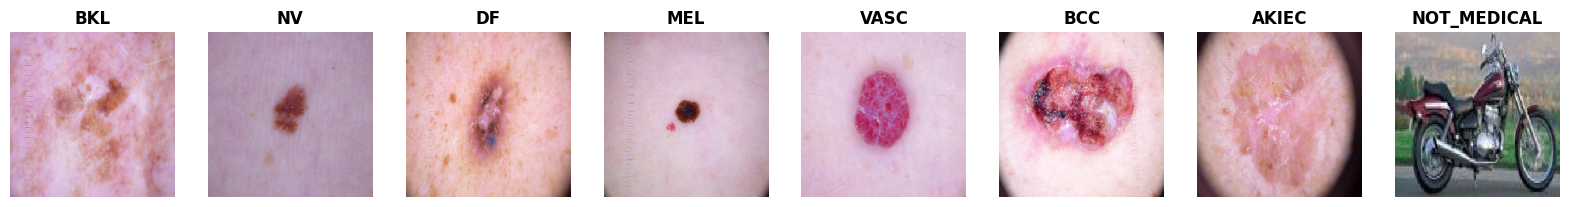

In [2]:
classes = full_df['dx'].unique()
plt.figure(figsize=(20, 5))
for i, label in enumerate(classes):
    sample = full_df[full_df['dx'] == label].iloc[0]
    img = tf.keras.utils.load_img(sample['path'], target_size=(224, 224))
    plt.subplot(1, 8, i+1)
    plt.imshow(img)
    plt.title(label.upper(), fontweight='bold')
    plt.axis('off')
plt.show()

In [3]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_df, val_df = train_test_split(full_df, test_size=0.2, stratify=full_df['dx'], random_state=42)

train_gen = ImageDataGenerator(rescale=1./255, rotation_range=40, horizontal_flip=True).flow_from_dataframe(
    train_df, x_col='path', y_col='dx', target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical'
)

val_gen = ImageDataGenerator(rescale=1./255).flow_from_dataframe(
    val_df, x_col='path', y_col='dx', target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

Found 9292 validated image filenames belonging to 8 classes.
Found 2323 validated image filenames belonging to 8 classes.


In [4]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2

base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = True # Full brain unfreeze for >82% target

x = GlobalAveragePooling2D()(base_model.output)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
x = Dense(512, activation='relu', kernel_regularizer=l2(0.0001))(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
predictions = Dense(8, activation='softmax')(x) 

model = Model(inputs=base_model.input, outputs=predictions)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
print("✅ 8-Class Model Compiled Successfully.")

I0000 00:00:1777658030.281518      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777658030.287403      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ 8-Class Model Compiled Successfully.


In [5]:
from sklearn.utils import class_weight

# Balanced weights for 1-2% gap control
cw = class_weight.compute_class_weight('balanced', classes=np.unique(train_df['dx']), y=train_df['dx'])
cw_dict = dict(enumerate(cw))

callbacks = [
    tf.keras.callbacks.ModelCheckpoint('Master_OOD_Model.keras', monitor='val_accuracy', save_best_only=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=12, restore_best_weights=True)
]

print("🚀 Starting 50-Epoch Training...")
history = model.fit(
    train_gen,
    epochs=50,
    validation_data=val_gen,
    class_weight=cw_dict,
    callbacks=callbacks
)

🚀 Starting 50-Epoch Training...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50


I0000 00:00:1777658091.540015     133 service.cc:152] XLA service 0x7eb0dc006ab0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777658091.540052     133 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777658091.540055     133 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777658102.003473     133 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1777658201.609382     133 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


291/291 ━━━━━━━━━━━━━━━━━━━━ 538s 1s/step - accuracy: 0.3697 - loss: 1.9655 - val_accuracy: 0.5613 - val_loss: 1.3790 - learning_rate: 1.0000e-04
Epoch 2/50
291/291 ━━━━━━━━━━━━━━━━━━━━ 168s 577ms/step - accuracy: 0.5965 - loss: 1.0826 - val_accuracy: 0.6121 - val_loss: 1.1875 - learning_rate: 1.0000e-04
Epoch 3/50
291/291 ━━━━━━━━━━━━━━━━━━━━ 175s 601ms/step - accuracy: 0.6614 - loss: 0.9138 - val_accuracy: 0.7546 - val_loss: 0.7907 - learning_rate: 1.0000e-04
Epoch 4/50
291/291 ━━━━━━━━━━━━━━━━━━━━ 169s 579ms/step - accuracy: 0.6954 - loss: 0.7992 - val_accuracy: 0.7409 - val_loss: 0.8149 - learning_rate: 1.0000e-04
Epoch 5/50
291/291 ━━━━━━━━━━━━━━━━━━━━ 170s 582ms/step - accuracy: 0.7112 - loss: 0.6804 - val_accuracy: 0.7555 - val_loss: 0.8224 - learning_rate: 1.0000e-04
Epoch 6/50
291/291 ━━━━━━━━━━━━━━━━━━━━ 161s 552ms/step - accuracy: 0.7409 - loss: 0.5981 - val_accuracy: 0.7770 - val_loss: 0.7185 - learning_rate: 1.0000e-04
Epoch 7/50
291/291 ━━━━━━━━━━━━━━━━━━━━ 156s 535ms/ste

Final Training: 93.32% | Final Validation: 82.82%
Generalization Gap: 10.49%
73/73 ━━━━━━━━━━━━━━━━━━━━ 40s 401ms/step


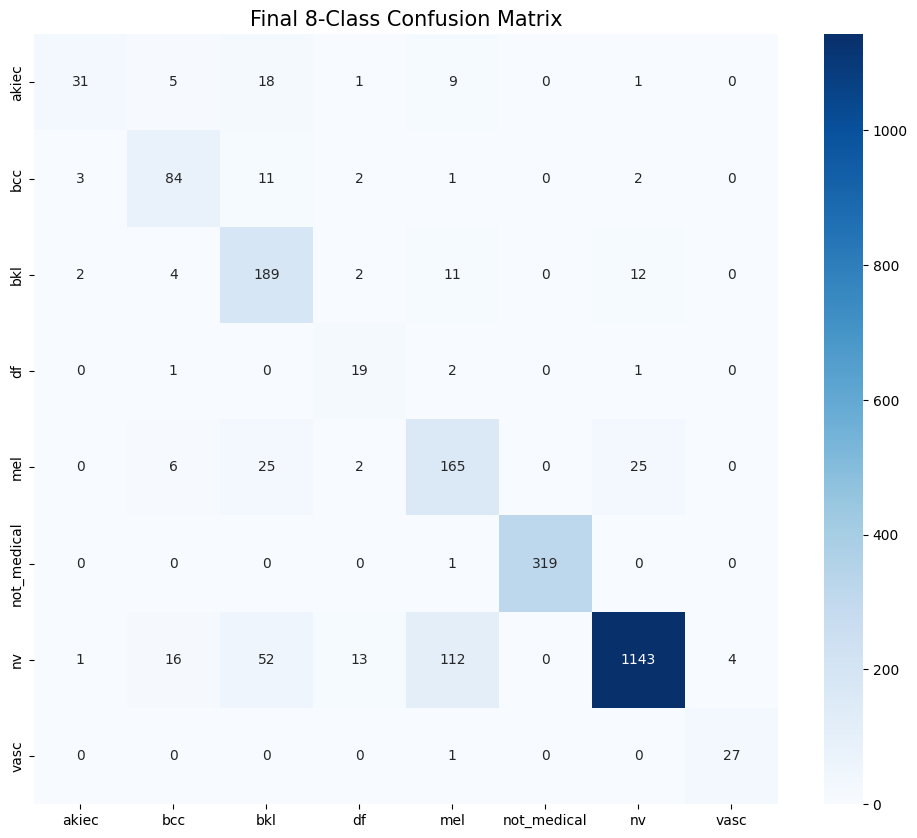


--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

       akiec       0.84      0.48      0.61        65
         bcc       0.72      0.82      0.77       103
         bkl       0.64      0.86      0.73       220
          df       0.49      0.83      0.61        23
         mel       0.55      0.74      0.63       223
 not_medical       1.00      1.00      1.00       320
          nv       0.97      0.85      0.91      1341
        vasc       0.87      0.96      0.92        28

    accuracy                           0.85      2323
   macro avg       0.76      0.82      0.77      2323
weighted avg       0.88      0.85      0.86      2323



In [6]:
from sklearn.metrics import confusion_matrix, classification_report

# 1. Accuracies
final_train = history.history['accuracy'][-1]
final_val = history.history['val_accuracy'][-1]
print(f"Final Training: {final_train*100:.2f}% | Final Validation: {final_val*100:.2f}%")
print(f"Generalization Gap: {abs(final_train - final_val)*100:.2f}%")

# 2. Confusion Matrix
val_gen.reset()
Y_pred = model.predict(val_gen)
y_pred = np.argmax(Y_pred, axis=1)
y_true = val_gen.classes
class_labels = list(val_gen.class_indices.keys())

plt.figure(figsize=(12, 10))
sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Final 8-Class Confusion Matrix', fontsize=15)
plt.show()

print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(y_true, y_pred, target_names=class_labels))
